# eval-suite — profile report

This notebook loads the latest test-run directory and renders the per-condition success rates for every (model, robot) pair.

**Order:**

1. Reproducibility check — every saved record carries a hash of its own contents; this confirms all five pass.
2. A four-bucket summary chart per (model, robot) pair (wording / visuals / physics / robot-type).
3. The headline observation from this round: a wording change drops both arm models from working to never working on the same task.
4. Per-robot detail (Google Robot, WidowX, Unitree Go1).
5. Where a real-robot reference number exists, comparison to it.
6. Sample rollouts and a rollout inspector.
7. What this report deliberately does *not* claim.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Markdown, Video, display

from eval_suite._types import canonical_dims
from eval_suite.analysis import (
    calibration_overlay,
    canonical_profile_for_sweep,
    load_sweep_dir,
    profile_for_bundle,
)
from eval_suite.rollout_data import RolloutMetadata

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path("..").resolve()
results_root = REPO_ROOT / "results"
candidate_dirs = sorted([p for p in results_root.glob("sweep_*") if p.is_dir()])
SWEEP_DIR = Path(os.environ.get("EVAL_SWEEP_DIR", candidate_dirs[-1] if candidate_dirs else ""))
assert SWEEP_DIR.exists(), f"no test-run dir at {SWEEP_DIR}"

bundle = load_sweep_dir(SWEEP_DIR)
display(Markdown(f"Loaded **{len(bundle.sweeps)} test runs** from `{SWEEP_DIR.name}`."))
for s in bundle.sweeps:
    display(Markdown(
        f"- `{s.model_name}` on `{s.embodiment}/{s.task_name}` — "
        f"{len(s.cell_results)} test conditions, hash `{s.manifest.run_id[:12]}…`"
    ))

Loaded **5 test runs** from `sweep_20260516T072703Z`.

- `octo-base` on `google_robot/pick_coke_can` — 29 test conditions, hash `bb3fca910e1f…`

- `octo-base` on `widowx/spoon_on_towel` — 1 test conditions, hash `20e9972c8aea…`

- `random-locomotion-12dof` on `unitree_go1/unitree_go1_joystick` — 12 test conditions, hash `9a27cc77941c…`

- `rt1:rt_1_tf_trained_for_000400120` on `google_robot/pick_coke_can` — 29 test conditions, hash `77dc485e65a9…`

- `rt1:rt_1_x_tf_trained_for_002272480_step` on `widowx/spoon_on_towel` — 1 test conditions, hash `09303b6e6ad5…`

## 1 — Reproducibility check

Each test run saves a `manifest.json` listing every input that affects the result (model checkpoint hash, simulator commit, hardware, every seed, the per-condition successes). The manifest also stores a SHA256 of its own contents. `Manifest.verify()` recomputes the hash and compares.

The relevant code, in `eval_suite/manifest.py`:

```python
def verify(self) -> bool:
    if not self.run_id:
        return False
    if hash_dict(self._hashable_payload()) != self.run_id:
        return False
    # (signature check below, when a submitter signature is present)
    ...
```

`_hashable_payload` returns every field of the manifest except `run_id` itself. `hash_dict` is a SHA256 over canonical JSON of that payload. So a single bit flipped anywhere in the recorded inputs changes the hash.

Results for the five runs in this report dir:

In [2]:
rows = ["| Model | Robot / task | Manifest hash (first 16 chars) | Conditions | Trials/cond. | `verify()` |",
        "|---|---|---|---|---|---|"]
for s in bundle.sweeps:
    m = s.manifest
    rows.append(
        f"| `{m.model.name}` | {m.embodiment} / `{m.task_name}` | "
        f"`{m.run_id[:16]}` | {len(m.cells)} | {m.trials_per_cell} | {m.verify()} |"
    )
display(Markdown("\n".join(rows)))

| Model | Robot / task | Manifest hash (first 16 chars) | Conditions | Trials/cond. | `verify()` |
|---|---|---|---|---|---|
| `octo-base` | google_robot / `pick_coke_can` | `bb3fca910e1f724e` | 29 | 20 | True |
| `octo-base` | widowx / `spoon_on_towel` | `20e9972c8aeadaad` | 1 | 20 | True |
| `random-locomotion-12dof` | unitree_go1 / `unitree_go1_joystick` | `9a27cc77941c9682` | 12 | 10 | True |
| `rt1:rt_1_tf_trained_for_000400120` | google_robot / `pick_coke_can` | `77dc485e65a90519` | 29 | 20 | True |
| `rt1:rt_1_x_tf_trained_for_002272480_step` | widowx / `spoon_on_towel` | `09303b6e6ad5f577` | 1 | 20 | True |

## 2 — Four-bucket summary chart

The four buckets are **wording, visuals, physics, robot type** — the kinds of shift a generalist model is expected to handle. Each Task declares how its concrete conditions map to these buckets via a small dict on the Task class.

For the Google Robot pick-coke-can task (in `eval_suite/tasks/simpler_env.py`):

```python
class GoogleRobotPickCokeCan:
    canonical_axis_map: dict[str, CanonicalDim] = {
        "orientation":   "physics",   # can pose on the table
        "lighting":      "visuals",
        "background":    "visuals",
        "distractor":    "visuals",   # extra objects in scene
        "table_texture": "visuals",
        "paraphrase":    "language",
    }
```

Per (model, task), the analysis layer pools every condition that touches a given bucket and reports the mean + a 95% Wilson confidence interval. The chart below has one panel per (model, robot) pair with the four bars, worst measured bar in red. A bucket with no conditions is rendered gray ("not measured"). The robot-type bar is gray everywhere because it's a cross-task dimension — comparing the same model on two robots is deferred to v1 (stratified bootstrap + deployment-relevance weights).

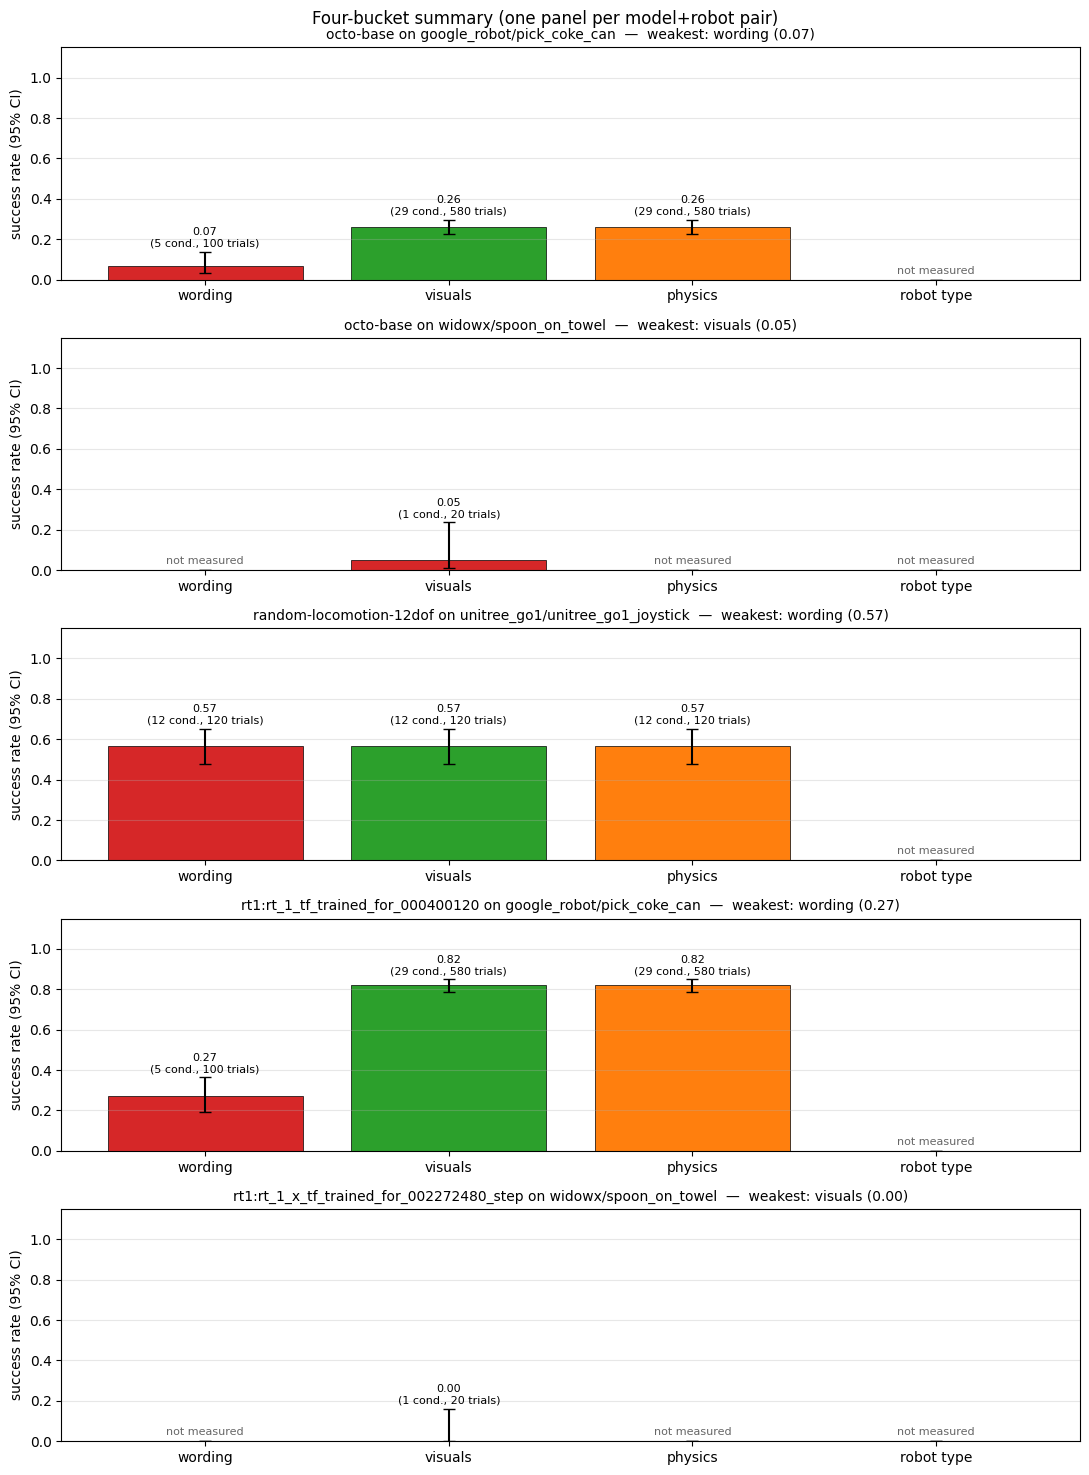

_Note: scores are per-(model, task). Cross-task averaging is intentionally deferred — see section 10._

In [3]:
DIMS = list(canonical_dims())
DIM_COLORS = {"language": "#1f77b4", "visuals": "#2ca02c", "physics": "#ff7f0e", "embodiment": "#9467bd"}
DIM_LABEL = {"language": "wording", "visuals": "visuals", "physics": "physics", "embodiment": "robot type"}

canonical_profiles = [canonical_profile_for_sweep(s) for s in bundle.sweeps]
fig, axes = plt.subplots(len(canonical_profiles), 1, figsize=(11, 3.0 * len(canonical_profiles)), squeeze=False)
axes = axes[:, 0]
for ax, profile in zip(axes, canonical_profiles):
    means = [profile.per_dim[d].mean for d in DIMS]
    lows = [max(0.0, profile.per_dim[d].mean - profile.per_dim[d].wilson_ci_low) for d in DIMS]
    highs = [max(0.0, profile.per_dim[d].wilson_ci_high - profile.per_dim[d].mean) for d in DIMS]
    n_cells = [profile.per_dim[d].n_cells for d in DIMS]
    n_trials = [profile.per_dim[d].n_trials for d in DIMS]
    colors = []
    for d in DIMS:
        if profile.per_dim[d].n_cells == 0:
            colors.append("#dddddd")
        elif d == profile.worst_dim_name:
            colors.append("#d62728")
        else:
            colors.append(DIM_COLORS[d])
    ax.bar(range(len(DIMS)), means, yerr=[lows, highs], capsize=4, color=colors, edgecolor="black", linewidth=0.5)
    for i, (d, nc, nt) in enumerate(zip(DIMS, n_cells, n_trials)):
        if nc == 0:
            ax.text(i, 0.02, "not measured", ha="center", va="bottom", fontsize=8, color="#666")
        else:
            ax.text(i, means[i] + max(highs[i], 0.02) + 0.015,
                    f"{means[i]:.2f}\n({nc} cond., {nt} trials)",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(DIMS)))
    ax.set_xticklabels([DIM_LABEL[d] for d in DIMS])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("success rate (95% CI)")
    ax.grid(axis="y", alpha=0.3)
    title = f"{profile.sweep.model_name} on {profile.sweep.embodiment}/{profile.sweep.task_name}"
    if profile.worst_dim_name is not None:
        title += f"  —  weakest: {DIM_LABEL[profile.worst_dim_name]} ({profile.worst_dim_score:.2f})"
    ax.set_title(title, fontsize=10)
fig.suptitle("Four-bucket summary (one panel per model+robot pair)", fontsize=12)
fig.tight_layout()
plt.show()
display(Markdown(
    "_Note: scores are per-(model, task). Cross-task averaging is intentionally deferred — see section 10._"
))

## 3 — Observation from this round: a wording change drops both arm models to zero

v0 adds 5 conditions to the Google Robot grid that vary only the instruction wording. The scene, lighting, table, and can position are identical to the upright baseline; the only difference is the string passed to the model's language input.

The wording is plumbed through a `_CellSpec.instruction_override` field. When the Adapter builds the env, the Task stashes the override on the env object; the Task's `instruction_for` hook reads it back at every step (the Adapter calls that hook to decide what to pass to `policy.reset(...)`):

```python
# eval_suite/tasks/simpler_env.py
def build_env(self, cell):
    spec = _GOOGLE_ROBOT_CELL_SPECS[cell]
    env = gym.make(spec.env_name, **kwargs)
    if spec.instruction_override is not None:
        env._eval_suite_instruction_override = spec.instruction_override
    return env

def instruction_for(self, env):
    override = getattr(env, "_eval_suite_instruction_override", None)
    if override is not None:
        return str(override)
    return env.get_language_instruction()  # SimplerEnv's default
```

This is the pattern any per-cell override would use — store on the env at build time, read back via the hook. No protocol changes, no plumbing through the Adapter. The 5 phrasings, with the trials-each result:

In [4]:
PARAPHRASES = [
    ("base",         '"pick up the coke can"',          "original phrasing"),
    ("synonym",      '"grab the soda"',                 "synonym swap"),
    ("descriptive",  '"lift the red can on the table"', "descriptive paraphrase"),
    ("ood_walk",     '"walk forward to the can"',       "impossible (the arm has no legs)"),
    ("ood_stand",    '"stand up and grab the can"',     "impossible (also legged)"),
]
ARM_SWEEPS = [s for s in bundle.sweeps if s.embodiment == "google_robot"]

rows = ["| Wording | Instruction the model received | What kind of shift | " +
        " | ".join(s.model_name for s in ARM_SWEEPS) + " |",
        "|---|---|---|" + "|".join(["---"] * len(ARM_SWEEPS)) + "|"]
for lvl, instr, kind in PARAPHRASES:
    cells_for_lvl = []
    for s in ARM_SWEEPS:
        match = [c for c in s.cell_results if c.cell.axes.get("paraphrase") == lvl]
        if not match:
            cells_for_lvl.append("—")
            continue
        c = match[0]
        rate = c.successes / c.n_trials if c.n_trials else 0.0
        cells_for_lvl.append(f"{c.successes}/{c.n_trials} ({rate:.2f})")
    rows.append(f"| `{lvl}` | {instr} | {kind} | " + " | ".join(cells_for_lvl) + " |")
display(Markdown("\n".join(rows)))
display(Markdown(
    "\nFor RT-1, the score drops from 0.75 on the original wording to 0.00 on the descriptive paraphrase, "
    "with 95% Wilson CIs [0.53, 0.89] and [0.00, 0.16] respectively — the intervals don't overlap. "
    "For Octo, even the synonym swap collapses to 0/20. The impossible cells (last two rows) score zero for "
    "both models, which is unsurprising but worth recording — the relevant signal there isn't the score, "
    "it's that the model still emits actions instead of refusing or flagging the instruction as out-of-scope. "
    "You can see that in the rollout inspector below."
))

| Wording | Instruction the model received | What kind of shift | octo-base | rt1:rt_1_tf_trained_for_000400120 |
|---|---|---|---|---|
| `base` | "pick up the coke can" | original phrasing | 6/20 (0.30) | 15/20 (0.75) |
| `synonym` | "grab the soda" | synonym swap | 0/20 (0.00) | 12/20 (0.60) |
| `descriptive` | "lift the red can on the table" | descriptive paraphrase | 0/20 (0.00) | 0/20 (0.00) |
| `ood_walk` | "walk forward to the can" | impossible (the arm has no legs) | 0/20 (0.00) | 0/20 (0.00) |
| `ood_stand` | "stand up and grab the can" | impossible (also legged) | 1/20 (0.05) | 0/20 (0.00) |


For RT-1, the score drops from 0.75 on the original wording to 0.00 on the descriptive paraphrase, with 95% Wilson CIs [0.53, 0.89] and [0.00, 0.16] respectively — the intervals don't overlap. For Octo, even the synonym swap collapses to 0/20. The impossible cells (last two rows) score zero for both models, which is unsurprising but worth recording — the relevant signal there isn't the score, it's that the model still emits actions instead of refusing or flagging the instruction as out-of-scope. You can see that in the rollout inspector below.

## 4 — Per-condition view: Google Robot arm

29 conditions on the Google Robot arm: 24 from the original variant grid + 5 new wording conditions. Each bar below is one condition with a Wilson 95% confidence interval. Conditions on the weakest axis are highlighted in red.

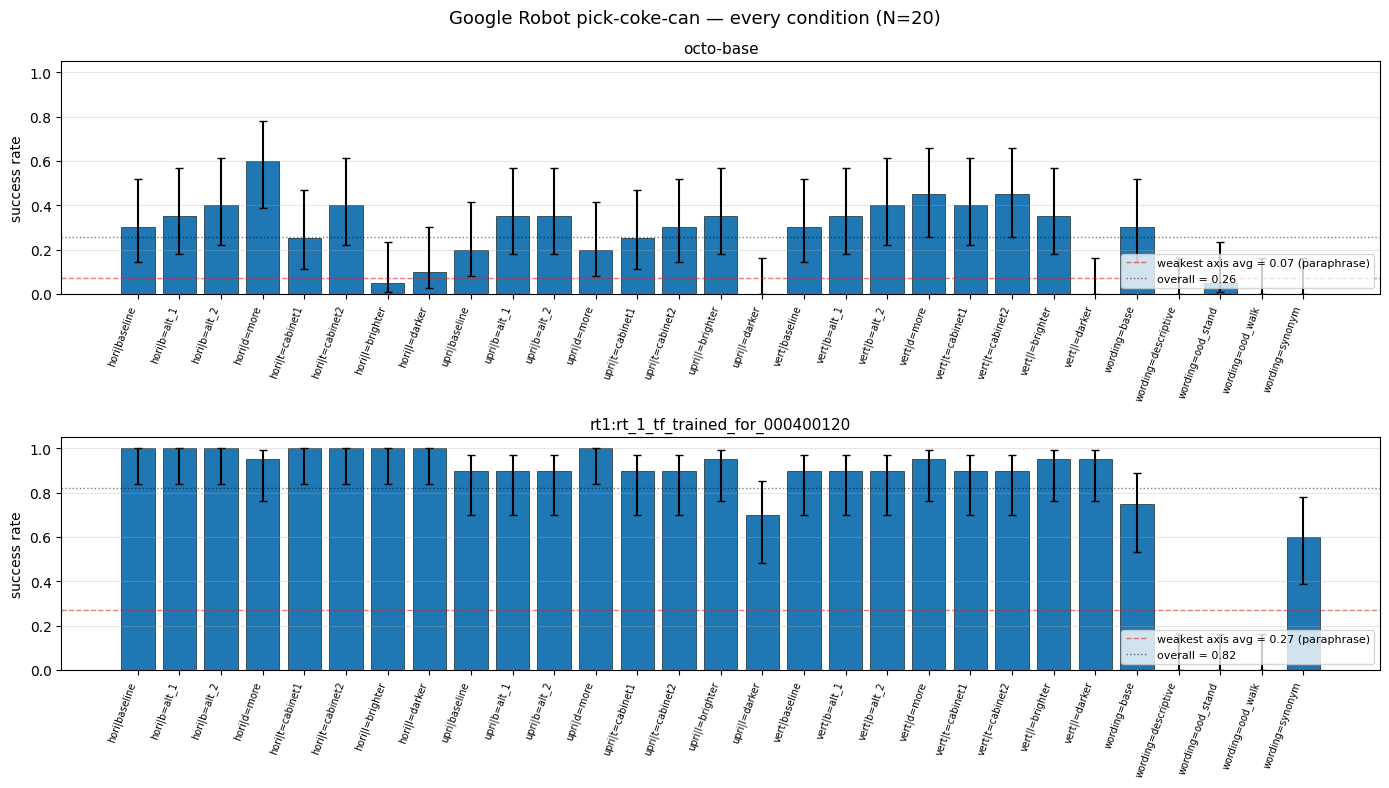

In [5]:
def _short_cell_label(axes: dict[str, str]) -> str:
    return "/".join(f"{k[0]}={v}" for k, v in sorted(axes.items()) if v != "base") or "baseline"

google_reports = profile_for_bundle(bundle, task_key="google_robot_pick_coke_can")
fig, axes = plt.subplots(len(google_reports), 1, figsize=(14, 4 * len(google_reports)), sharex=False)
if len(google_reports) == 1: axes = [axes]
for ax, report in zip(axes, google_reports):
    cells_ = sorted(report.sweep.cell_results,
                    key=lambda c: (c.cell.axes.get("paraphrase", "0"),
                                   c.cell.axes.get("orientation", ""),
                                   c.cell.axes.get("lighting", "")))
    labels = []
    for c in cells_:
        if "paraphrase" in c.cell.axes:
            labels.append(f"wording={c.cell.axes['paraphrase']}")
        else:
            labels.append(f"{c.cell.axes.get('orientation', '?')[:4]}|{_short_cell_label({k: v for k, v in c.cell.axes.items() if k != 'orientation'})}")
    means = [c.success_rate for c in cells_]
    lows = [c.success_rate - c.wilson_ci_low for c in cells_]
    highs = [c.wilson_ci_high - c.success_rate for c in cells_]
    worst_axis = report.worst_axis_name
    worst_level = min(report.per_axis[worst_axis].items(), key=lambda kv: kv[1])[0] if worst_axis in report.per_axis else None
    colors = ["#d62728" if (worst_axis in c.cell.axes and c.cell.axes[worst_axis] == worst_level) else "#1f77b4" for c in cells_]
    ax.bar(range(len(cells_)), means, yerr=[lows, highs], capsize=3, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_xticks(range(len(cells_)))
    ax.set_xticklabels(labels, rotation=70, ha="right", fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("success rate")
    ax.axhline(report.worst_axis_score, color="#d62728", linestyle="--", linewidth=1, alpha=0.6,
               label=f"weakest axis avg = {report.worst_axis_score:.2f} ({report.worst_axis_name})")
    ax.axhline(report.overall_success_rate, color="black", linestyle=":", linewidth=1, alpha=0.5,
               label=f"overall = {report.overall_success_rate:.2f}")
    ax.set_title(f"{report.sweep.model_name}", fontsize=11)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Google Robot pick-coke-can — every condition (N=20)", fontsize=13)
fig.tight_layout()
plt.show()

## 5 — WidowX arm

Second arm task (different size, different gripper conventions). The `WidowXSpoonOnTowel` Task ships a single cell — the clean condition — by current Task definition. Widening to a per-condition grid is a Task-level edit (list more `_CellSpec`s, same shape as `GoogleRobotPickCokeCan`), not a framework change.

The numbers below are close to the published real-robot numbers for these checkpoints (0.000 for RT-1-X, ~0.10 for Octo, from the SimplerEnv paper Table 4) — useful as a pipeline sanity check on a different embodiment.

In [6]:
widowx_reports = profile_for_bundle(bundle, task_key="widowx_spoon_on_towel")
for r in widowx_reports:
    total_s = sum(c.successes for c in r.sweep.cell_results)
    total_n = sum(c.n_trials for c in r.sweep.cell_results)
    display(Markdown(
        f"- `{r.sweep.model_name}` on `widowx/spoon_on_towel`: {total_s}/{total_n} = {r.overall_success_rate:.2f}"
    ))

- `octo-base` on `widowx/spoon_on_towel`: 1/20 = 0.05

- `rt1:rt_1_x_tf_trained_for_002272480_step` on `widowx/spoon_on_towel`: 0/20 = 0.00

## 6 — Unitree Go1 (different robot class)

Go1 is a four-legged dog, not an arm. The action space is 12 joint targets, not the 7-D end-effector vector both arms use. To accept this without changing every existing interface, v0 added a sibling action type and a union:

```python
# eval_suite/_types.py
@dataclass(frozen=True)
class Action:           # 7-DoF EEF: arms
    world_vector: NDArrayF32
    rot_axangle:  NDArrayF32
    gripper:      NDArrayF32
    ...

@dataclass(frozen=True)
class JointAction:      # N-DoF joint targets: legged, aerial, multi-arm
    vector: NDArrayF32
    ...

ActionLike = Action | JointAction
```

The Go1 task also uses a different physics engine (MuJoCo MJX) than the arms (SAPIEN via ManiSkill2). It runs through a separate Adapter (`MujocoPlaygroundAdapter`) for the action shape, but the rest of the substrate — `run_sweep`, `Manifest`, the per-rollout layout, the analysis layer, this notebook — is the same code that runs the arms.

**About the policy.** The numbers below are from a *random-twitch* policy, not a trained walking controller. The point is to confirm the framework absorbs the embodiment with no contract changes; integrating a real Go1 policy is named as mechanical follow-up.

Survival rate (= didn't fall over before the step budget runs out) over 200 steps:

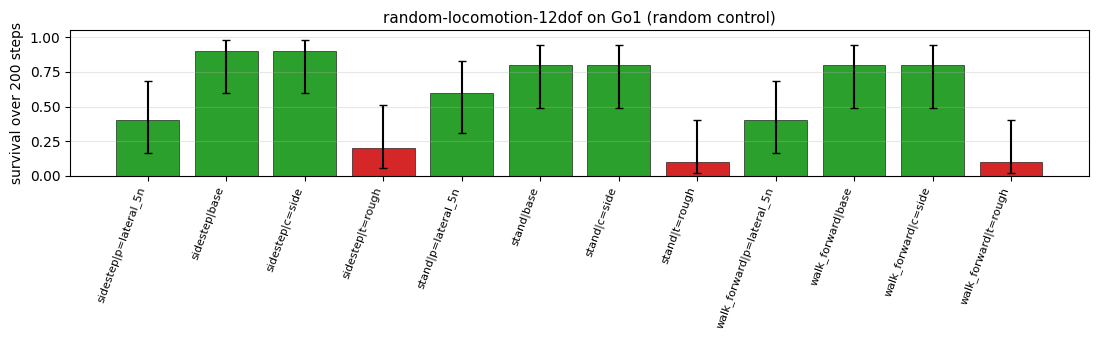

In [7]:
go1_reports = profile_for_bundle(bundle, task_key="unitree_go1_unitree_go1_joystick")
for report in go1_reports:
    cells_ = sorted(report.sweep.cell_results,
                    key=lambda c: (c.cell.axes.get("task_family", ""),
                                   c.cell.axes.get("terrain", ""),
                                   c.cell.axes.get("camera", ""),
                                   c.cell.axes.get("perturbation", "")))
    def _go1_lbl(a):
        tf = a.get("task_family", "?")
        parts = []
        if a.get("terrain", "flat") != "flat": parts.append(f"t={a['terrain']}")
        if a.get("camera", "front") != "front": parts.append(f"c={a['camera']}")
        if a.get("perturbation", "none") != "none": parts.append(f"p={a['perturbation']}")
        return tf + ("|" + ",".join(parts) if parts else "|base")
    labels = [_go1_lbl(c.cell.axes) for c in cells_]
    means = [c.success_rate for c in cells_]
    lows = [c.success_rate - c.wilson_ci_low for c in cells_]
    highs = [c.wilson_ci_high - c.success_rate for c in cells_]
    worst_axis = report.worst_axis_name
    worst_level = min(report.per_axis[worst_axis].items(), key=lambda kv: kv[1])[0] if worst_axis in report.per_axis else None
    colors = ["#d62728" if (worst_axis in c.cell.axes and c.cell.axes[worst_axis] == worst_level) else "#2ca02c" for c in cells_]
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.bar(range(len(cells_)), means, yerr=[lows, highs], capsize=3, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_xticks(range(len(cells_)))
    ax.set_xticklabels(labels, rotation=70, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("survival over 200 steps")
    ax.set_title(f"{report.sweep.model_name} on Go1 (random control)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

## 7 — Sim vs. published real-robot numbers

For one (model, task) pair, the SimplerEnv paper Table 3 publishes a real-robot success rate: 0.293 for Octo-base on Google Robot pick-coke-can. The suite stores published references in a small registry JSON keyed by `(task_key, model_key)`:

```json
// calibration/real_perf.json (snippet)
{
  "entries": [
    {
      "task_key": "google_robot_pick_coke_can",
      "model_key": "octo-base",
      "value": 0.293,
      "source": "SimplerEnv paper Table 3",
      "source_url": "https://arxiv.org/abs/2405.05941",
      "hardware": "Everyday Robots Google Robot (real)",
      "date_iso": "2024-05-09",
      "contributor": "SimplerEnv authors (Li et al.)",
      "notes": "..."
    },
    ...
  ]
}
```

`analysis.calibration_overlay` looks up the entry at render time, so a v2.0 ingestion pipeline can swap the file mid-run. The provenance fields (source, hardware, date) are deliberate — a real number with no provenance isn't a reference, it's a rumor. One data point isn't a calibration claim; it's a check that the sim and the published real number are in the same ballpark.

In [8]:
all_reports = google_reports + widowx_reports
rows = ["| Model | Robot / task | Sim score (this run) | Published real | Δ |",
        "|---|---|---|---|---|"]
for r in all_reports:
    ov = calibration_overlay(r)
    sim = f"{ov['sim']:.3f}" if ov['sim'] is not None else "—"
    real = f"{ov['real']:.3f}" if ov['real'] is not None else "_no published number_"
    delta = f"{ov['delta']:+.3f}" if ov['delta'] is not None else "—"
    rows.append(f"| `{r.sweep.model_name}` | {r.sweep.embodiment} / `{r.sweep.task_name}` | {sim} | {real} | {delta} |")
display(Markdown("\n".join(rows)))

| Model | Robot / task | Sim score (this run) | Published real | Δ |
|---|---|---|---|---|
| `octo-base` | google_robot / `pick_coke_can` | 0.259 | 0.293 | -0.034 |
| `rt1:rt_1_tf_trained_for_000400120` | google_robot / `pick_coke_can` | 0.821 | 0.853 | -0.032 |
| `octo-base` | widowx / `spoon_on_towel` | 0.050 | 0.477 | -0.427 |
| `rt1:rt_1_x_tf_trained_for_002272480_step` | widowx / `spoon_on_towel` | 0.000 | 0.000 | +0.000 |

## 8 — Sample rollouts (one success + one failure per run)

The cell below picks one successful and one failed attempt from each run and embeds the video, with the cell axes and exact instruction printed above the clip.

In [9]:
def _pick_rollout(sweep_label: str, want_success: bool):
    videos_root = SWEEP_DIR / sweep_label / "videos"
    if not videos_root.is_dir():
        return None
    for meta_path in sorted(videos_root.rglob("metadata.json")):
        try:
            meta = RolloutMetadata.load(meta_path)
        except Exception:
            continue
        if meta.success != want_success:
            continue
        mp4 = meta_path.parent / "rollout.mp4"
        if mp4.exists():
            return mp4, meta
    return None

for s in bundle.sweeps:
    for want in (True, False):
        picked = _pick_rollout(s.label, want)
        if picked is None:
            display(Markdown(f"_{s.label}: no example {'success' if want else 'failure'} clip._"))
            continue
        mp4, meta = picked
        axis_chip = ", ".join(f"{k}={v}" for k, v in sorted(meta.cell_axes.items()) if v != "base") or "baseline"
        display(Markdown(
            f"**{s.label}** \u2014 example {'success' if want else 'failure'} "
            f"({axis_chip}, instruction `{meta.instruction!r}`)"
        ))
        display(Video(str(mp4), embed=True, width=320))

**octo_google_robot_pick_coke_can** — example success (background=alt_1, orientation=horizontal, instruction `'pick coke can'`)

**octo_google_robot_pick_coke_can** — example failure (background=alt_1, orientation=horizontal, instruction `'pick coke can'`)

**octo_widowx_spoon_on_towel** — example success (condition=clean, instruction `'put the spoon on the towel'`)

**octo_widowx_spoon_on_towel** — example failure (condition=clean, instruction `'put the spoon on the towel'`)

**random_go1_unitree_go1_joystick** — example success (camera=front, perturbation=lateral_5n, task_family=sidestep, terrain=flat, instruction `'locomote at vx=0.00 vy=0.40 wz=0.00'`)

**random_go1_unitree_go1_joystick** — example failure (camera=front, perturbation=lateral_5n, task_family=sidestep, terrain=flat, instruction `'locomote at vx=0.00 vy=0.40 wz=0.00'`)

**rt1_google_robot_pick_coke_can** — example success (background=alt_1, orientation=horizontal, instruction `'pick coke can'`)

**rt1_google_robot_pick_coke_can** — example failure (background=alt_1, orientation=upright, instruction `'pick coke can'`)

_rt1x_widowx_spoon_on_towel: no example success clip._

**rt1x_widowx_spoon_on_towel** — example failure (condition=clean, instruction `'put the spoon on the towel'`)

## 9 — Rollout inspector

Each individual attempt is saved as its own folder:

```
results/sweep_<timestamp>/<combo>/videos/<cell-slug>/seed_NNNN/
├── rollout.mp4         # h.264 video
├── trajectory.npz      # per-step actions, rewards, success, truncated (numpy arrays)
└── metadata.json       # the spec below, plus the exact instruction passed to the policy
```

The metadata schema (in `eval_suite/rollout_data.py`):

```python
@dataclass(frozen=True)
class RolloutMetadata:
    instruction:           str             # exact string passed to policy.reset()
    cell_axes:             dict[str, str]
    cell_slug:             str
    seed:                  int
    embodiment:            str
    task_name:             str
    model_name:            str
    model_checkpoint_id:   str             # sha256: ... or hf:revision
    success:               bool
    num_steps:             int
    elapsed_wall_seconds:  float
    action_dim:            int
    action_components:     list[str]       # names like "world_vector_x", "gripper"
    episode_stats:         dict[str, Any]  # whatever the env returned
```

The cell below picks the first rollout from each run. Edit the `inspect_rollout(...)` call to point at any specific seed dir.

### `google_robot__pick_coke_can__background=alt_1,distractor=base,lighting=base,orientation=horizontal,table_texture=base` / seed_0000

**Instruction:** `pick coke can`  
**Conditions:** `{'background': 'alt_1', 'distractor': 'base', 'lighting': 'base', 'orientation': 'horizontal', 'table_texture': 'base'}`  
**Model:** `octo-base` (checkpoint `hf:rail-berkeley/octo-base…`)  
**Outcome:** success=False, steps=80, wall=15.6s

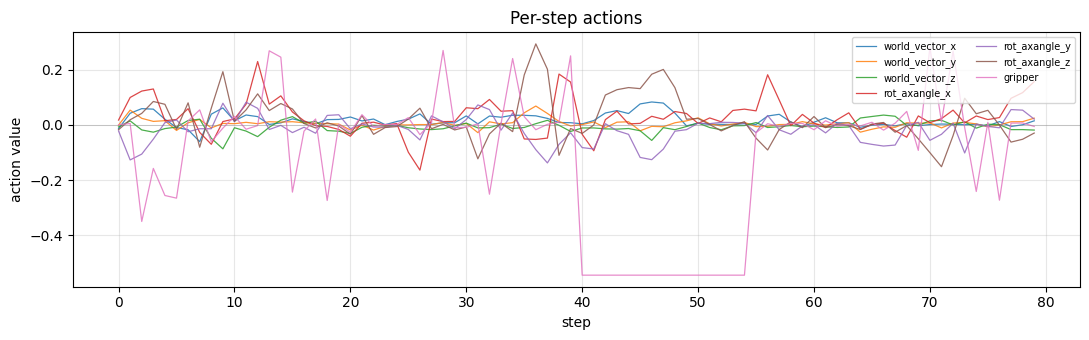

### `widowx__spoon_on_towel__condition=clean` / seed_0000

**Instruction:** `put the spoon on the towel`  
**Conditions:** `{'condition': 'clean'}`  
**Model:** `octo-base` (checkpoint `hf:rail-berkeley/octo-base…`)  
**Outcome:** success=False, steps=60, wall=32.5s

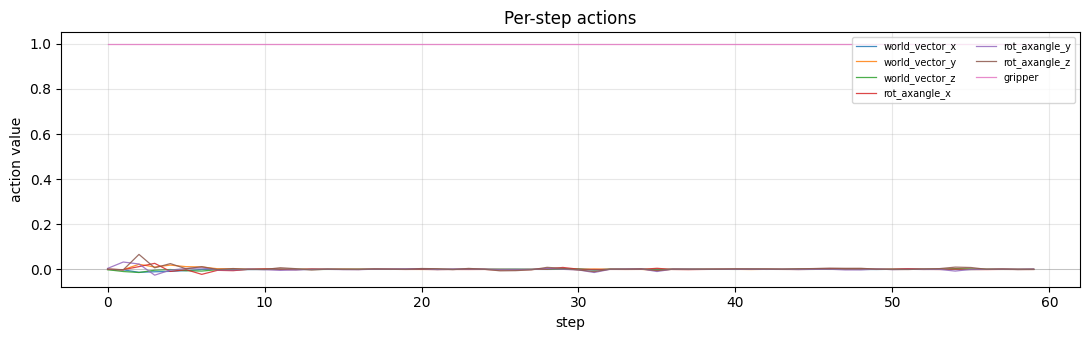

### `unitree_go1__unitree_go1_joystick__camera=front,perturbation=lateral_5n,task_family=sidestep,terrain=flat` / seed_0000

**Instruction:** `locomote at vx=0.00 vy=0.40 wz=0.00`  
**Conditions:** `{'camera': 'front', 'perturbation': 'lateral_5n', 'task_family': 'sidestep', 'terrain': 'flat'}`  
**Model:** `random-locomotion-12dof` (checkpoint `mock:random-locomotion-policy:dim=12:bound=0.3:s…`)  
**Outcome:** success=False, steps=83, wall=0.8s

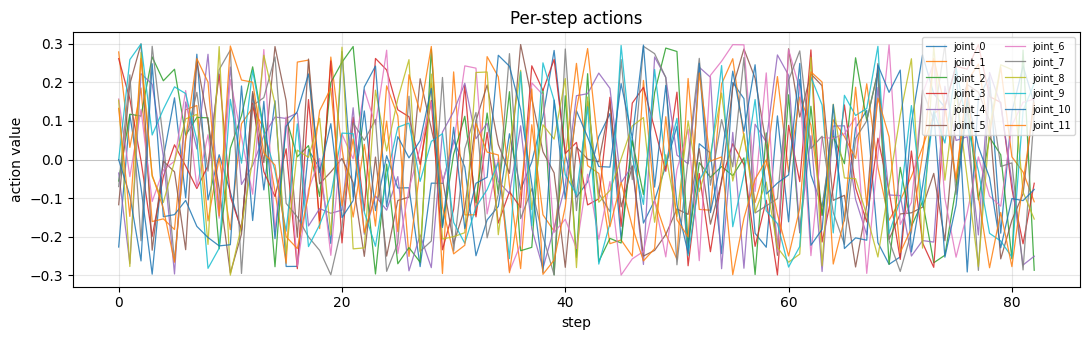

### `google_robot__pick_coke_can__background=alt_1,distractor=base,lighting=base,orientation=horizontal,table_texture=base` / seed_0000

**Instruction:** `pick coke can`  
**Conditions:** `{'background': 'alt_1', 'distractor': 'base', 'lighting': 'base', 'orientation': 'horizontal', 'table_texture': 'base'}`  
**Model:** `rt1:rt_1_tf_trained_for_000400120` (checkpoint `sha256:487c574b6c1d34f44200e62560fb9a98156c9f70b…`)  
**Outcome:** success=True, steps=12, wall=2.6s

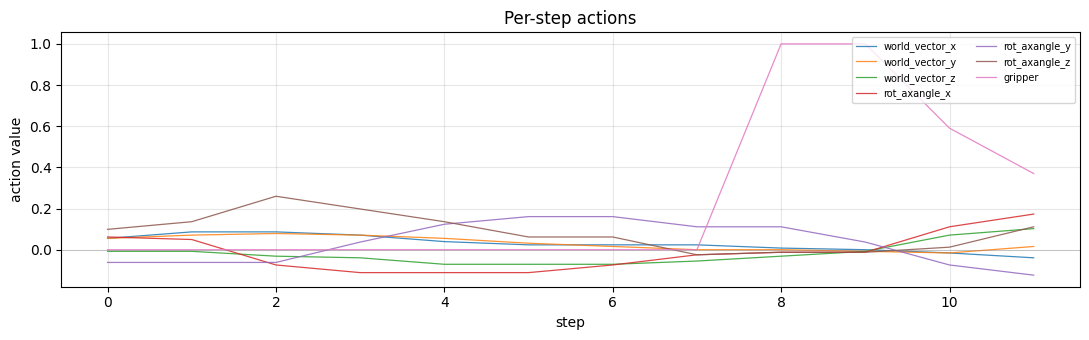

### `widowx__spoon_on_towel__condition=clean` / seed_0000

**Instruction:** `put the spoon on the towel`  
**Conditions:** `{'condition': 'clean'}`  
**Model:** `rt1:rt_1_x_tf_trained_for_002272480_step` (checkpoint `sha256:d87a9a914b449a7292c0c8611ef4f3b632b06ae41…`)  
**Outcome:** success=False, steps=29, wall=10.9s

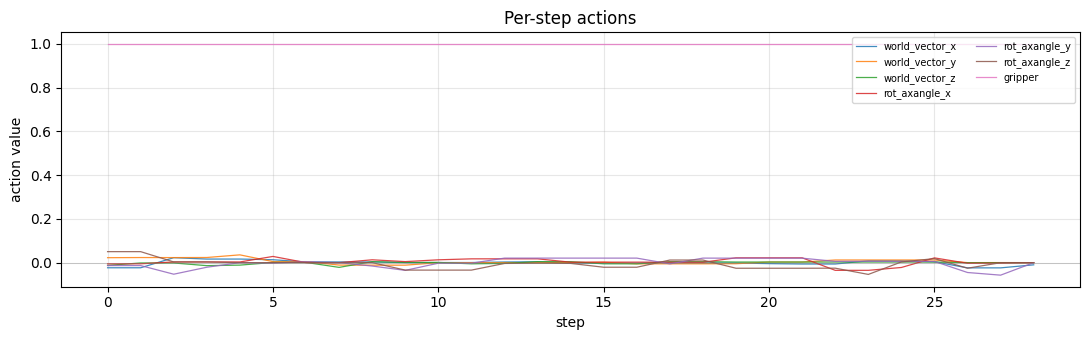

In [10]:
def list_rollouts(combo_dir: Path, max_show: int = 5) -> list[Path]:
    videos_root = combo_dir / "videos"
    if not videos_root.is_dir():
        return []
    return sorted(videos_root.rglob("seed_*"))[:max_show]

def inspect_rollout(rollout_dir: Path) -> None:
    from eval_suite.rollout_data import Trajectory
    if not rollout_dir.is_dir():
        display(Markdown(f"_no rollout at `{rollout_dir}`_"))
        return
    meta_path = rollout_dir / "metadata.json"
    traj_path = rollout_dir / "trajectory.npz"
    video_path = rollout_dir / "rollout.mp4"
    if not meta_path.exists() or not traj_path.exists():
        display(Markdown(f"_rollout at `{rollout_dir}` is missing metadata or trajectory._"))
        return
    meta = RolloutMetadata.load(meta_path)
    traj = Trajectory.load(traj_path)
    display(Markdown(f"### `{rollout_dir.parent.name}` / seed_{meta.seed:04d}"))
    display(Markdown(
        f"**Instruction:** `{meta.instruction}`  \n"
        f"**Conditions:** `{meta.cell_axes}`  \n"
        f"**Model:** `{meta.model_name}` (checkpoint `{meta.model_checkpoint_id[:48]}…`)  \n"
        f"**Outcome:** success={meta.success}, steps={meta.num_steps}, wall={meta.elapsed_wall_seconds:.1f}s"
    ))
    if video_path.exists():
        display(Video(str(video_path), embed=True, width=320))
    if traj.action.size > 0:
        fig, ax = plt.subplots(1, 1, figsize=(11, 3.5))
        for i, comp_name in enumerate(meta.action_components):
            if i >= traj.action.shape[1]: break
            ax.plot(traj.t, traj.action[:, i], label=comp_name, linewidth=0.9, alpha=0.85)
        ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
        ax.set_xlabel("step"); ax.set_ylabel("action value")
        ax.set_title("Per-step actions")
        ax.legend(loc="upper right", fontsize=7, ncol=2)
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()

for sweep in bundle.sweeps:
    combo_dir = SWEEP_DIR / sweep.label
    options = list_rollouts(combo_dir, max_show=1)
    if options:
        inspect_rollout(options[0])

## 10 — What this notebook deliberately does not claim

- **No cross-task averaging.** Scores in the four-bucket chart are per-(model, task). Combining "language" scores across Google Robot and Go1 would require either deployment-relevance weights or a stratified bootstrap; both are deferred to v1.
- **No real embodiment-bucket score.** That bucket is gray in every panel above by design. It's a cross-task dimension — measurable only by comparing the same model on multiple robots — and is deferred to v1 alongside cross-task aggregation.
- **Go1 numbers are random control, not a model.** The point of that run is to confirm the substrate absorbs a different action class; a trained Go1 policy is named as mechanical follow-up.
- **Boundary cells score zero for everyone.** The impossible instructions (`"walk forward to the can"`, `"stand up and grab the can"`) produce 0/20 for both arm models. That number doesn't separate models; the per-step actions in the rollout inspector do.
- **One real-robot reference number.** Section 7's calibration table is one tier-B comparison + a few tier-C references. The tiering scheme (described in EXTENSION.md §4) is what scales as real-world data accrues; v0 ships one data point and a registry format, not a full calibration claim.